<a href="https://colab.research.google.com/github/SoumitraDas1/QuantumKAN/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task I

### 1) A simple quantum operation with Pennylane

In [1]:
!pip install pennylane

In [2]:
import pennylane as qml
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

 ***Device: 5 qubits***

In [3]:
dev = qml.device("default.qubit", wires=5)

In [4]:
@qml.qnode(dev)
def quantum_circuit():
    # (b) Hadamard on every qubit
    for i in range(5):
        qml.Hadamard(wires=i)

    # (c) CNOT chain: (0→1), (1→2), (2→3), (3→4)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    qml.CNOT(wires=[3, 4])

    # (d) SWAP qubits 0 and 4
    qml.SWAP(wires=[0, 4])

    # (e) Rotate-X by π/2 on qubit 2  (arbitrary choice)
    qml.RX(np.pi / 2, wires=2)

    return qml.state()

Final state vector (first 8 amplitudes shown):
  |00000⟩  0.125000-0.125000j
  |00001⟩  0.125000-0.125000j
  |00010⟩  0.125000-0.125000j
  |00011⟩  0.125000-0.125000j
  |00100⟩  0.125000-0.125000j
  |00101⟩  0.125000-0.125000j
  |00110⟩  0.125000-0.125000j
  |00111⟩  0.125000-0.125000j
  ...


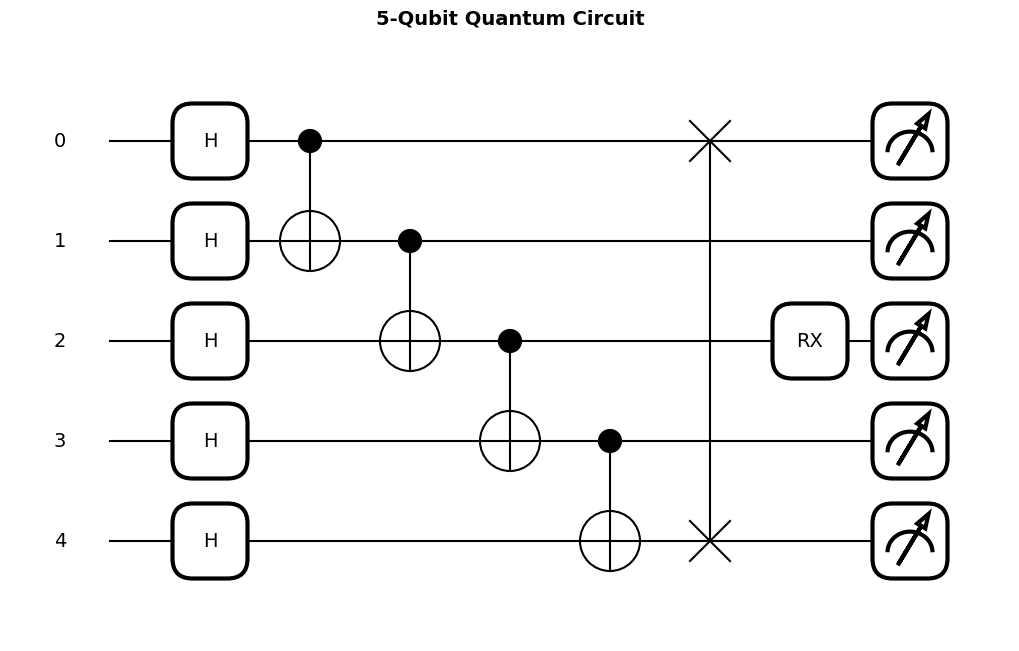

In [5]:
# ── Run & print state vector ───────────────────────────────────────────────────
state = quantum_circuit()
print("Final state vector (first 8 amplitudes shown):")
for idx, amp in enumerate(state[:8]):
    print(f"  |{idx:05b}⟩  {amp:.6f}")
print("  ...")

# Draw AFTER the circuit has been executed
fig, ax = qml.draw_mpl(quantum_circuit)()
ax.set_title("5-Qubit Quantum Circuit", fontsize=14, fontweight="bold", pad=12)
plt.show()